# Chicago Taxi Analytics Pipeline
## Analyzing 500k+ taxi trips using GCP BigQuery + PySpark
### Key Questions:
- Which company generates most revenue?
- Does payment type affect tipping?
- Which areas have highest fares?

In [43]:
!pip install pyspark

In [44]:
from pyspark.sql import SparkSession

spark = SparkSession.builder \
    .appName("TaxiAnalysis") \
    .getOrCreate()

sc = spark.sparkContext
print("Spark ready!", spark.version)

Spark ready! 4.0.2


In [3]:
from google.colab import auth
auth.authenticate_user()

In [4]:
from google.cloud import bigquery
client=bigquery.Client(project="savvy-ratio-473311-g5")
query="""select company,fare,tips,trip_total,trip_miles,trip_seconds,payment_type,pickup_community_area from `bigquery-public-data.chicago_taxi_trips.taxi_trips` WHERE fare > 1 AND trip_miles > 0 AND company IS NOT NULL LIMIT 500000"""
df_pandas=client.query(query).to_dataframe()
df_spark=spark.createDataFrame(df_pandas)
print(df_spark.show(truncate=False))

+--------+----+----+----------+----------+------------+------------+---------------------+
|company |fare|tips|trip_total|trip_miles|trip_seconds|payment_type|pickup_community_area|
+--------+----+----+----------+----------+------------+------------+---------------------+
|303 Taxi|0.01|0.0 |0.01      |9.4       |971.0       |Cash        |NaN                  |
|303 Taxi|0.01|0.0 |0.01      |6.1       |699.0       |Cash        |NaN                  |
|303 Taxi|0.01|0.0 |0.01      |2.5       |397.0       |Cash        |NaN                  |
|303 Taxi|0.01|0.0 |0.01      |9.5       |1225.0      |Cash        |NaN                  |
|303 Taxi|0.01|0.0 |0.01      |6.2       |1011.0      |Cash        |NaN                  |
|303 Taxi|0.01|0.0 |0.01      |3.4       |354.0       |Cash        |NaN                  |
|303 Taxi|0.01|0.0 |0.01      |4.5       |641.0       |Cash        |NaN                  |
|303 Taxi|0.01|0.0 |0.01      |10.8      |1226.0      |Cash        |NaN                  |

In [5]:
print(df_spark.schema)

StructType([StructField('company', StringType(), True), StructField('fare', DoubleType(), True), StructField('tips', DoubleType(), True), StructField('trip_total', DoubleType(), True), StructField('trip_miles', DoubleType(), True), StructField('trip_seconds', DoubleType(), True), StructField('payment_type', StringType(), True), StructField('pickup_community_area', DoubleType(), True)])


In [6]:
print(df_spark.count(), len(df_spark.columns))

500000 8


In [29]:
from pyspark.sql.functions import *
from pyspark.sql.types import *
for cols in df_spark.columns:
    dtype=df_spark.schema[cols].dataType
    if isinstance(dtype,(DoubleType,LongType)):
        nan_count=df_spark.filter(isnan(col(cols))).count()
        print(cols,"->",nan_count)
    else:
        print(cols,"-> STRING, skipping")


company -> STRING, skipping
fare -> 0
tips -> 0
trip_total -> 0
trip_miles -> 0
trip_seconds -> 7
payment_type -> STRING, skipping
pickup_community_area -> 136255


In [30]:
df_clean = df_spark.filter(col("company").isNotNull())

In [31]:
df_spark.groupBy("company").agg(avg(col("fare")).alias("avg_fare"),count("trip_total").alias("count_of_trip"),(avg(col("fare"))*count(col("trip_total"))).alias("Total_Revenue")).orderBy("Total_Revenue",ascending=False).show(truncate=False)

+------------------------------------+------------------+-------------+------------------+
|company                             |avg_fare          |count_of_trip|Total_Revenue     |
+------------------------------------+------------------+-------------+------------------+
|Flash Cab                           |14.315286118652871|259665       |3717178.7699999977|
|American United                     |12.377857754577583|73563        |910552.3499999908 |
|City Service                        |13.409871266387352|29596        |396878.55000000005|
|Taxi Affiliation Services           |19.11963051967546 |19974        |381895.4999999977 |
|Sun Taxi                            |13.323901021566403|22025        |293458.92000000004|
|Chicago Carriage Cab Corp           |13.286847231240145|10781        |143245.5          |
|Taxi Affiliation Service Yellow     |16.47652033570045 |7745         |127610.64999999998|
|Choice Taxi Association             |14.33692250279889 |8039         |115254.52000000028|

In [32]:
df_spark.groupBy("payment_type")\
          .agg(
                avg(col("fare")).alias("avg_fare"),
                avg(col("tips")).alias("avg_tips"),
                count("*").alias("total_trips")
          )\
          .orderBy("avg_tips",ascending=False)\
          .show(truncate=False)

+------------+------------------+---------------------+-----------+
|payment_type|avg_fare          |avg_tips             |total_trips|
+------------+------------------+---------------------+-----------+
|Mobile      |20.21875          |3.8521875000000003   |32         |
|Credit Card |16.130072779111654|3.359457783113232    |199920     |
|Way2ride    |8.625             |1.5749999999999997   |4          |
|Unknown     |14.723493975903613|0.8295180722891567   |83         |
|Prcard      |12.21078431372549 |0.3044117647058824   |102        |
|Pcard       |9.871212121212121 |0.20545454545454547  |66         |
|Cash        |12.626597602110799|0.0026227832882476706|299430     |
|Prepaid     |32.75             |0.0                  |1          |
|No Charge   |16.92718446601942 |0.0                  |309        |
|Dispute     |15.992452830188682|0.0                  |53         |
+------------+------------------+---------------------+-----------+



In [33]:
df_area = df_spark.filter(~isnan(col("pickup_community_area")))
print(df_area.count())

363745


In [12]:
df_company=df_clean.groupBy("company")\
          .agg(
                avg("fare").alias("avg_fare"),
                count("*").alias("total_trips"),
                (avg("fare") * count("*")).alias("total_revenue")
            )\
            .orderBy("total_revenue",ascending=False)\
            .limit(10)\
            .toPandas()
print(df_company.head())

                     company   avg_fare  total_trips  total_revenue
0                  Flash Cab  14.315286       259665     3717178.77
1            American United  12.377858        73563      910552.35
2               City Service  13.409871        29596      396878.55
3  Taxi Affiliation Services  19.119631        19974      381895.50
4                   Sun Taxi  13.323901        22025      293458.92


In [13]:
df_area.groupBy("pickup_community_area")\
          .agg(
                avg(col("fare")).alias("avg_fare"),
                avg(col("tips")).alias("avg_tips"),
                count("*").alias("total_trips")
          )\
          .orderBy("avg_tips",ascending=False)\
          .show(truncate=False)

+---------------------+------------------+------------------+-----------+
|pickup_community_area|avg_fare          |avg_tips          |total_trips|
+---------------------+------------------+------------------+-----------+
|76.0                 |39.12433890969052 |4.938520834048971 |29111      |
|56.0                 |29.518181818181834|3.733883211678823 |7535       |
|64.0                 |19.991772151898736|2.2530379746835436|79         |
|72.0                 |26.84807692307692 |2.1926923076923073|26         |
|77.0                 |22.775468164794013|1.4563836870578442|2403       |
|4.0                  |25.013871196036806|1.3923213021939136|1413       |
|6.0                  |20.4260160543824  |1.3479252241828161|13828      |
|3.0                  |22.281989844493797|1.2556521739130435|3151       |
|1.0                  |19.88369636963696 |1.226039603960396 |1515       |
|41.0                 |18.172057987492884|1.1716884593519046|1759       |
|5.0                  |22.507615546218

In [14]:
df_clean.groupBy("company")\
        .agg(
            avg("fare").alias("avg_fare"),
            count("*").alias("total_trips"),
            (avg("fare") * count("*")).alias("total_revenue")
        )\
        .orderBy("total_revenue", ascending=False)\
        .show(10, truncate=False)

+------------------------------------+------------------+-----------+------------------+
|company                             |avg_fare          |total_trips|total_revenue     |
+------------------------------------+------------------+-----------+------------------+
|Flash Cab                           |14.315286118652871|259665     |3717178.7699999977|
|American United                     |12.377857754577583|73563      |910552.3499999908 |
|City Service                        |13.409871266387352|29596      |396878.55000000005|
|Taxi Affiliation Services           |19.11963051967546 |19974      |381895.4999999977 |
|Sun Taxi                            |13.323901021566403|22025      |293458.92000000004|
|Chicago Carriage Cab Corp           |13.286847231240145|10781      |143245.5          |
|Taxi Affiliation Service Yellow     |16.47652033570045 |7745       |127610.64999999998|
|Choice Taxi Association             |14.33692250279889 |8039       |115254.52000000028|
|Dispatch Taxi Affili

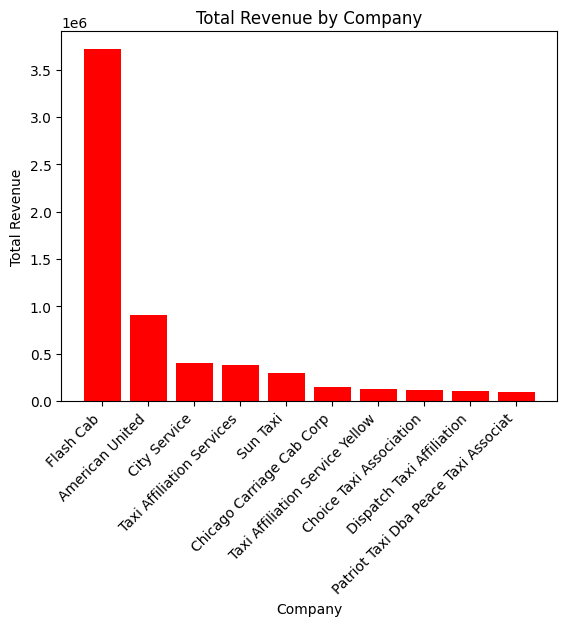

In [15]:
import matplotlib.pyplot as plt
x=df_company["company"]
y=df_company["total_revenue"]
plt.bar(x,y,color="red")
plt.xlabel("Company")
plt.ylabel("Total Revenue")
plt.xticks(rotation=45, ha="right")
plt.title("Total Revenue by Company")
plt.show()

In [16]:
cols=df_spark.columns
for col in cols:
  print(col)

company
fare
tips
trip_total
trip_miles
trip_seconds
payment_type
pickup_community_area


In [39]:
df_payment = df_spark.groupBy("payment_type")\
            .agg(
                avg("tips").alias("avg_tips"),
                count("*").alias("total_trips")
            )\
            .orderBy("total_trips", ascending=False)\
            .toPandas()
print(df_payment)

  payment_type  avg_tips  total_trips
0         Cash  0.002623       299430
1  Credit Card  3.359458       199920
2    No Charge  0.000000          309
3       Prcard  0.304412          102
4      Unknown  0.829518           83
5        Pcard  0.205455           66
6      Dispute  0.000000           53
7       Mobile  3.852188           32
8     Way2ride  1.575000            4
9      Prepaid  0.000000            1


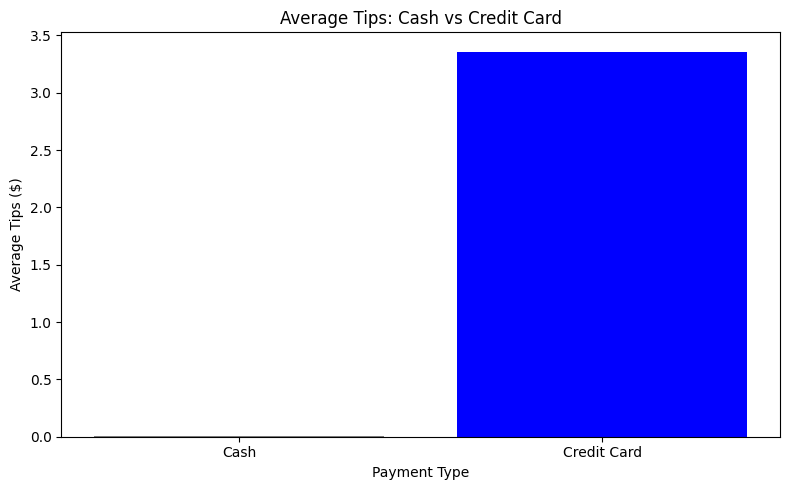

In [42]:
df_payment_filtered = df_payment[
    df_payment["payment_type"].isin(["Cash", "Credit Card"])
]
x = df_payment_filtered["payment_type"]
y = df_payment_filtered["avg_tips"]
plt.figure(figsize=(8, 5))
plt.bar(x, y, color=["gray", "blue"])
plt.xlabel("Payment Type")
plt.ylabel("Average Tips ($)")
plt.title("Average Tips: Cash vs Credit Card")
plt.tight_layout()
plt.show()

In [19]:
cols=df_area.columns
for col in cols:
  print(col)

company
fare
tips
trip_total
trip_miles
trip_seconds
payment_type
pickup_community_area


In [20]:
area=df_area.groupBy("pickup_community_area")\
            .agg(avg("fare").alias("avg_fare"))\
            .orderBy("avg_fare",ascending=False)\
            .limit(10)\
            .toPandas()
print(area.head())

   pickup_community_area   avg_fare
0                   54.0  48.250000
1                   76.0  39.124339
2                   75.0  38.443750
3                   49.0  31.220000
4                   52.0  30.250000


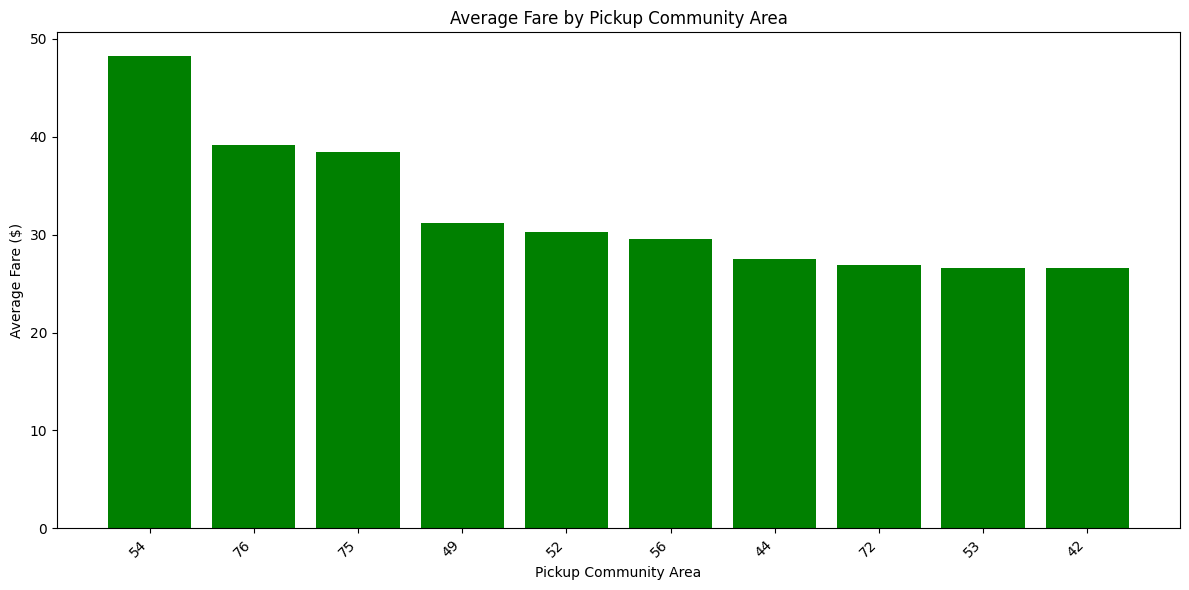

In [37]:
area_sorted = area.sort_values("avg_fare", ascending=False)
x = area_sorted["pickup_community_area"].astype(int).astype(str)
y = area_sorted["avg_fare"]
plt.figure(figsize=(12, 6))
plt.bar(range(len(x)), y, color="green")
plt.xticks(range(len(x)), x, rotation=45, ha="right")
plt.xlabel("Pickup Community Area")
plt.ylabel("Average Fare ($)")
plt.title("Average Fare by Pickup Community Area")
plt.tight_layout()
plt.show()

## Key Findings
- Flash Cab: highest revenue at $3.7M
- Mobile Users Tip More but considering based on the number of trips Credit Card have tipped more
- Area 54 has highest average fare